Let's explore this retail practice dataset which is taken from kaggle. 

The following questions we will be looking to answer involve: 

How does customer age and gender influence their purchasing behavior?

Are there discernible patterns in sales across different time periods?

What insights can be gleaned from the distribution of product prices within each category?

Which product categories hold the highest appeal among customers?

How do customers adapt their shopping habits during seasonal trends?

Are there distinct purchasing behaviors based on the number of items bought per transaction?


In [55]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt 
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/mohammadtalib786/retail-sales-dataset/retail_sales_dataset.csv


In [56]:
df=pd.read_csv('/kaggle/input/datasets/mohammadtalib786/retail-sales-dataset/retail_sales_dataset.csv')
print("done")

done


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


Many of the variables seem to either objects or integers. There seems to be no missing data here as the number of non-null data is the same across all categories so that we can use it. 
Date's data type is object now, let's change it into datetime. But first let's check to make sure there is no missing data for this dataset. 

In [58]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Now that we have done so, we can recontinue our datetime adjustment. 

In [59]:

df['Date']=pd.to_datetime(df['Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


Let's zoom into each year for datetime. Let's divide the date segments into various time measures in order to see how retail sales change with time. 

In [60]:
df['Year']=df['Date'].dt.year
df['Month']=df['Date'].dt.strftime('%Y-%m')
df['Quarter']=df['Date'].dt.to_period('Q').dt.strftime('%Y-Q%q')

Let's check to ensure it has been added to the table. 

In [61]:
df.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month,Quarter
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,2023-11,2023-Q4
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,2023-02,2023-Q1
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,2023-01,2023-Q1
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,2023-05,2023-Q2
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,2023-05,2023-Q2
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30,2023,2023-04,2023-Q2
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50,2023,2023-03,2023-Q1
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100,2023,2023-02,2023-Q1
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600,2023,2023-12,2023-Q4
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200,2023,2023-10,2023-Q4


The data set seems to only contain 2023 data. Let's investigate that further. 

In [62]:
df['Year'].value_counts()

Year
2023    998
2024      2
Name: count, dtype: int64

Thus it contains mainly 2023 data and just 2 values from 2024. Since the 2024 data is too few to make analyse.  Let's filter to only 2023. 

In [63]:
mask=df['Year']==2023
df_2023=df[mask]

df_2023['Year'].value_counts()

Year
2023    998
Name: count, dtype: int64

In [64]:
df_2023.shape

(998, 12)

There are 998 rows and 12 columns. Thus there are 998 transactions across the period of 2023.

In [65]:
df_2023.drop_duplicates().shape

(998, 12)

There are no duplicates inside the 2023 data. 

In [66]:
df_2023.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount,Year
count,998.000000,998,998.000000,998.000000,998.000000,998.000000,998.0
mean,500.640281,2023-07-02 15:40:45.691382784,41.377756,2.515030,179.719439,455.380762,2023.0
min,1.000000,2023-01-01 00:00:00,18.000000,1.000000,25.000000,25.000000,2023.0
25%,251.250000,2023-04-08 00:00:00,29.000000,1.000000,30.000000,60.000000,2023.0
50%,500.500000,2023-06-29 00:00:00,42.000000,3.000000,50.000000,135.000000,2023.0
75%,750.750000,2023-10-04 00:00:00,53.000000,4.000000,300.000000,900.000000,2023.0
max,1000.000000,2023-12-31 00:00:00,64.000000,4.000000,500.000000,2000.000000,2023.0
std,288.924735,NaN,13.688342,1.132751,189.541154,559.420064,0.0


The median age seems to be 42 therefore targeting the older demographic. The median total amount is 135 units while the median price per unit item is 50. 

In [67]:
df_2023.groupby(['Product Category', 'Gender']).size()

Product Category  Gender
Beauty            Female    166
                  Male      140
Clothing          Female    174
                  Male      177
Electronics       Female    170
                  Male      171
dtype: int64

Females tend to buy more beauty products than male while they buy around the same amount for clothing and electronics. Therefore, to target
female consumers it may be better to push out more beauty products. 

In [68]:
df_2023.groupby('Gender')['Total Amount'].agg(['count','median'])

,count,median
Gender,,
Female,510,150.0
Male,488,120.0


On average, there is a greater number of females buying in the year of 2023 and a greater total median amount spent than males. 

In [69]:
df_2023.groupby('Product Category')['Total Amount'].agg(['count','median'])

,count,median
Product Category,,
Beauty,306,120.0
Clothing,351,120.0
Electronics,341,150.0


The product categories are clothing, electronics and beauty. The median total amount per item represents the total amount an average consumer buys in one transaction is 120 for beauty or 120 for clothes  or 150 for Electronics. 
Since the median price per item is around 50. So they would be buying 2 or 3 items in one single transaction. 

Let's delve into which product categories hold the most appeal for buyers.

In [70]:
df_by_month=df_2023.groupby(['Month']).sum(numeric_only=True).reset_index()

df_by_month[['Month', 'Total Amount']]

,Month,Total Amount
0,2023-01,35450
1,2023-02,44060
2,2023-03,28990
3,2023-04,33870
4,2023-05,53150
5,2023-06,36715
6,2023-07,35465
7,2023-08,36960
8,2023-09,23620
9,2023-10,46580


In [71]:
df_2023_category=df_2023.groupby('Product Category')['Total Amount'].sum()
df_2023_category

Product Category
Beauty         142015
Clothing       155580
Electronics    156875
Name: Total Amount, dtype: int64

<Axes: xlabel='Product Category'>

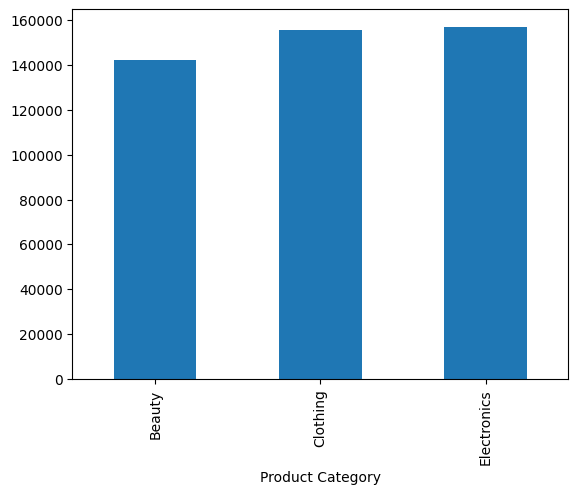

In [72]:
df_2023_category.plot(x='Product Category', y='Total Amount', kind='bar')

Therefore, Electronics is the product that gathers the highest total spending, followed by clothing. 

In [73]:
df_quarter_category=df_2023.groupby(['Quarter', 'Product Category'])['Total Amount'].sum(numeric_only=True).reset_index()
df_quarter_category

,Quarter,Product Category,Total Amount
0,2023-Q1,Beauty,37010
1,2023-Q1,Clothing,42750
2,2023-Q1,Electronics,28740
3,2023-Q2,Beauty,35350
4,2023-Q2,Clothing,41565
5,2023-Q2,Electronics,46820
6,2023-Q3,Beauty,32200
7,2023-Q3,Clothing,30680
8,2023-Q3,Electronics,33165
9,2023-Q4,Beauty,37455


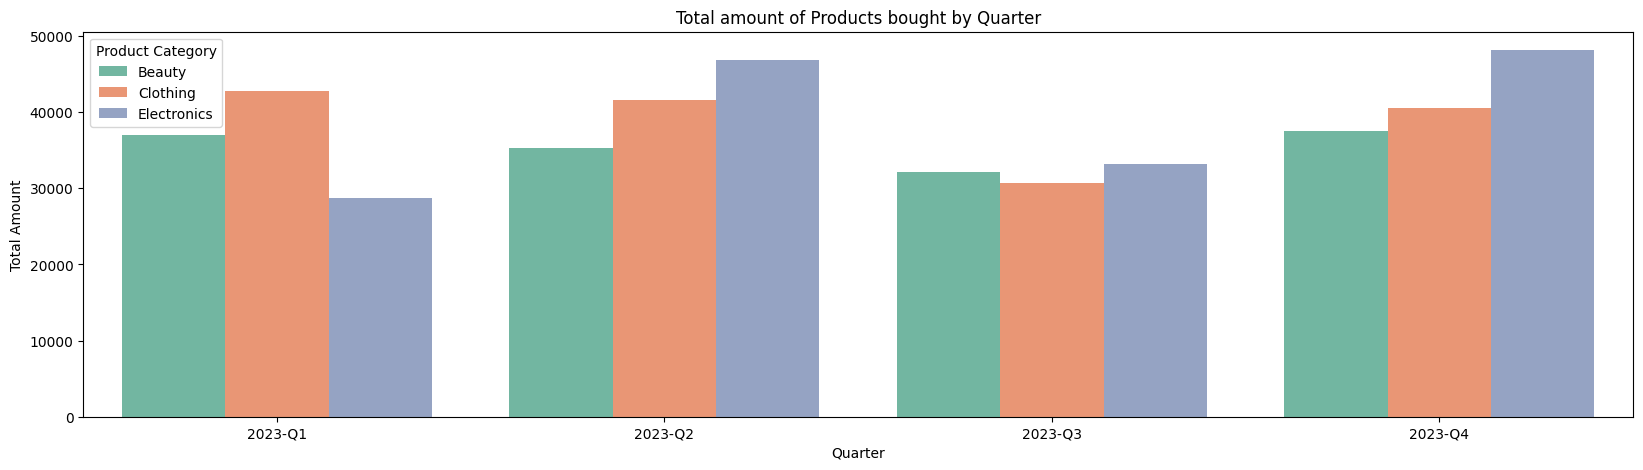

In [74]:
plt.figure(figsize = (20, 5))
p = sns.barplot(
    data = df_quarter_category,
    x = 'Quarter',
    y = 'Total Amount',
    hue = 'Product Category',
    palette='Set2')
plt.xlabel("Quarter")
plt.ylabel("Total Amount")
plt.title("Total amount of Products bought by Quarter")
plt.show()

Here you can see how the products perform across quarters. 
In Quarter 1, clothing is more popular than the other two while in Quarter 2 & 4, Electronics  is more popular. While in Quarter 3, the total amount bought for all 3 is lowest in the year. 

Possible reasons could be due to the new year, people often buy more clothes for festive occasions. 

Now let's look more into how the products are doing across the different months in the quarter. 

In [75]:
df_month_category=df_2023.groupby(['Month', 'Product Category'])['Total Amount'].sum(numeric_only=True).reset_index()

df_month_category

,Month,Product Category,Total Amount
0,2023-01,Beauty,12430
1,2023-01,Clothing,13125
2,2023-01,Electronics,9895
3,2023-02,Beauty,14035
4,2023-02,Clothing,14560
5,2023-02,Electronics,15465
6,2023-03,Beauty,10545
7,2023-03,Clothing,15065
8,2023-03,Electronics,3380
9,2023-04,Beauty,11905


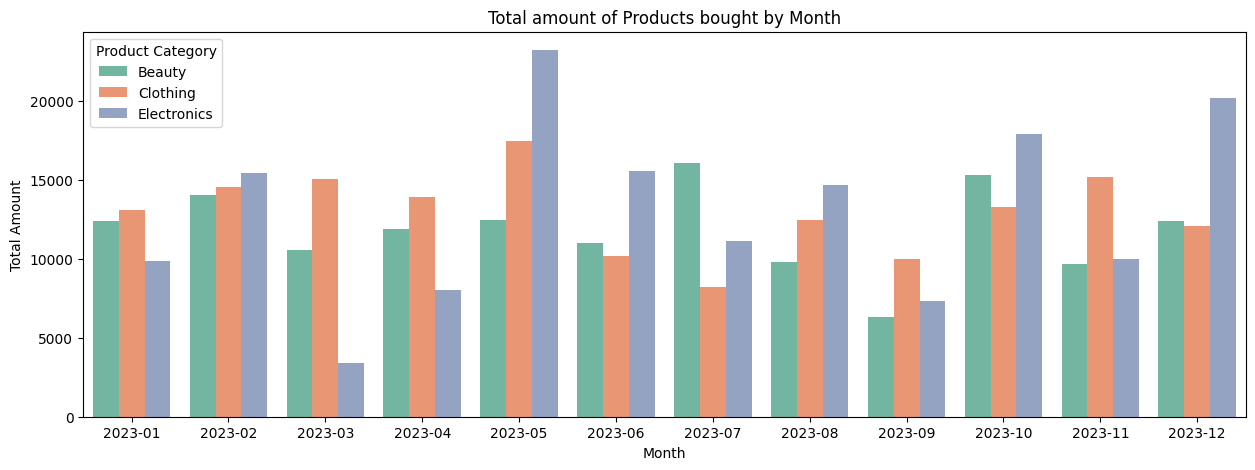

In [76]:
plt.figure(figsize = (15, 5))
p = sns.barplot(
    data = df_month_category,
    x = 'Month',
    y = 'Total Amount',
    hue = 'Product Category',
    palette='Set2')
plt.xlabel("Month")
plt.ylabel("Total Amount")
plt.title("Total amount of Products bought by Month")
plt.show()

Among the product categories, we can see that among the various months,  the total amount of products bought are the highest in May, while the lowest is in September. 

Let's look into quarter volume. 

In [77]:
df_2023_price=df_2023.groupby('Product Category')['Price per Unit'].agg(['mean', 'median', 'max']).reset_index()

df_2023_price

,Product Category,mean,median,max
0,Beauty,183.022876,50.0,500
1,Clothing,174.287749,50.0,500
2,Electronics,182.346041,50.0,500


<Axes: xlabel='Product Category', ylabel='Price per Unit'>

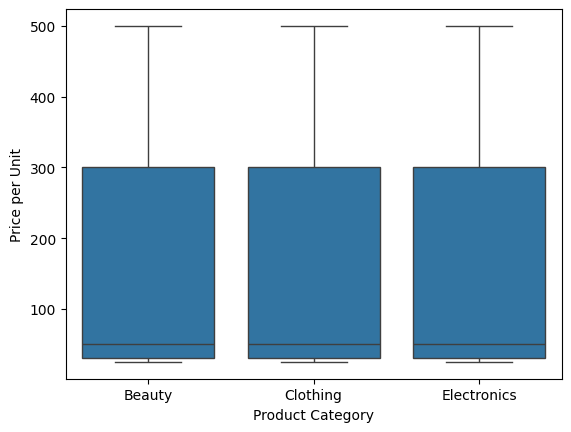

In [78]:
sns.boxplot(
    data=df_2023,
    x='Product Category',
    y='Price per Unit'
)

They show similar distribution of product pricing for all categories with the same median pricing of around 50 per unit and a large variation in pricing, with the most expensive item being $500 across all categories.

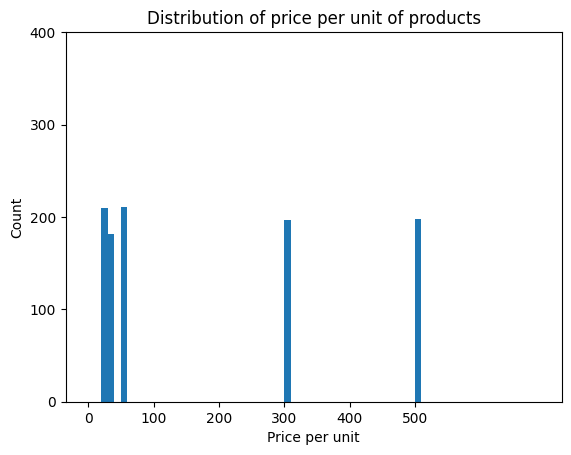

In [79]:
plt.hist(df_2023['Price per Unit'], bins=range(0, 700, 10))
plt.xticks(range(0, 600, 100))
plt.yticks(range(0, 500, 100))
plt.xlabel('Price per unit')
plt.ylabel('Count')
plt.title('Distribution of price per unit of products')
plt.show();

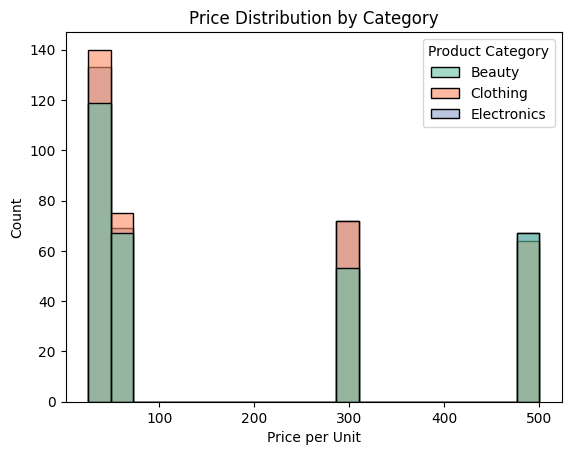

In [80]:
sns.histplot(data=df_2023, x='Price per Unit', hue='Product Category', palette='Set2', bins=20,alpha=0.6)
plt.title('Price Distribution by Category')
plt.show()

There is a distribution of prices, for example, there is more clothing on the lower end compared to electronics and Beauty. 

At the 300 price point, there is more However, when its 500 per unit, then there are more products for Electronics at that higher price point. 

This graph seems a little confusing to further understand, let's look at a table instead. 

In [81]:
df_2023.groupby(['Price per Unit','Product Category']).size()

Price per Unit  Product Category
25              Beauty              63
                Clothing            75
                Electronics         72
30              Beauty              56
                Clothing            65
                Electronics         61
50              Beauty              67
                Clothing            75
                Electronics         69
300             Beauty              53
                Clothing            72
                Electronics         72
500             Beauty              67
                Clothing            64
                Electronics         67
dtype: int64

At price 25-50 people tend to buy more clothes, followed by electronics then beauty. 
At price 300, people woould buy either clothes or electronics while less likely to buy beauty. 
At price 500, people are more likely to buy electronics or beauty items then clothing. 

####Thus in conclusion we have answered the following questions: 

How does customer age and gender influence their purchasing behavior?

The median customer age is 42. Females tend to buy more beauty products than males. Hence, it may be good to push out more beauty products to female consumers.

Are there discernible patterns in sales across different time periods?

Yes customers buy more product items in May while not buying as much in September.

What insights can be gleaned from the distribution of product prices within each category?

The distribution of prices seem to be quite similar.

Which product categories hold the highest appeal among customers?

At price 25-50 people tend to buy more clothes, followed by electronics then beauty.  At price 300, people woould buy either clothes or electronics while less likely to buy beauty.  At price 500, people are more likely to buy electronics or beauty items then clothing.

In general, customers have spent more on electronics and clothing over beauty products.

How do customers adapt their shopping habits during seasonal trends?

Customers tend to buy more clothes during Q1 possibly due to the new year while they buy more electronics during Q2 and Q4.

Are there distinct purchasing behaviors based on the number of items bought per transaction?

In one single transaction, customers usually purchase 2 or 3 items which adds up to around $100-$150.

However, we have yet to explore questions like what are the relationships between age, spending, and product preferences? 

Or why did quarter 3 show a dip in sales? 

Further research could explore this. Furthermore, this dataset only focuses on the year 2023 and lacks data for other years, to get a better prediction of shoppers preferences, it may be better to have their preferences for a few years to accurately predict. 